<a href="https://colab.research.google.com/github/jadghazi/codealpha_tasks/blob/Car-Price-Prediction/Car_Prediction_Data_Science_task.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

sns.set(style="whitegrid")

In [3]:
url = "https://raw.githubusercontent.com/jadghazi/codealpha_tasks/refs/heads/Car-Price-Prediction/car%20data.csv"
df = pd.read_csv(url)


# Display the first few rows
df.head()
#  Basic Exploration
print("Data Info:\n")
df.info()

print("\nMissing Values:\n")
print(df.isnull().sum())

print("\nSummary Statistics:\n")
print(df.describe())


Data Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB

Missing Values:

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64

Summary Statistics:

              Year  Selling_Price  Present_Price     Driven_kms       Owner
count   301.000000     301.000000    

In [ ]:
#DATA PREPROCESSING
df['Car_Age'] = 2025 - df['Year']         # Create car age
df.drop(['Car_Name', 'Year'], axis=1, inplace=True)  # Drop unused columns

# One-hot encode categorical features
df = pd.get_dummies(df, columns=['Fuel_Type', 'Selling_type', 'Transmission'], drop_first=True)

# Show processed data
df.head()


,Selling_Price,Present_Price,Driven_kms,Owner,Car_Age,Fuel_Type_Diesel,Fuel_Type_Petrol,Selling_type_Individual,Transmission_Manual
0,3.35,5.59,27000,0,11,False,True,False,True
1,4.75,9.54,43000,0,12,True,False,False,True
2,7.25,9.85,6900,0,8,False,True,False,True
3,2.85,4.15,5200,0,14,False,True,False,True
4,4.60,6.87,42450,0,11,True,False,False,True


R² Score: 0.849
Mean Absolute Error (MAE): 1.22
Mean Squared Error (MSE): 3.48
Root Mean Squared Error (RMSE): 1.87


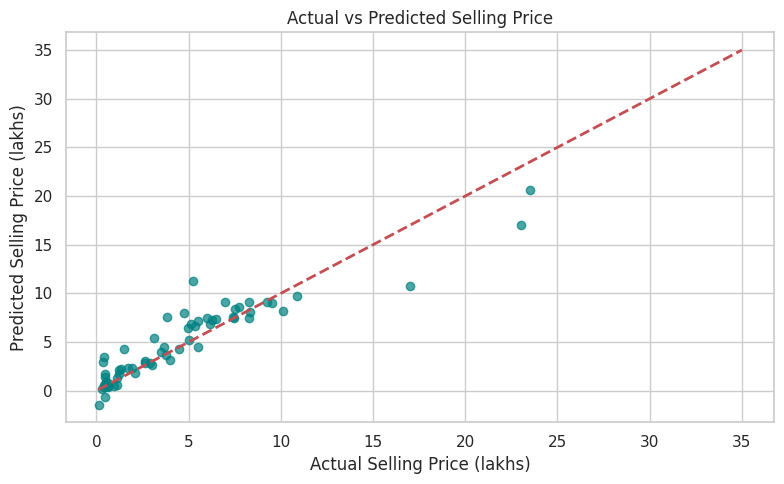

In [ ]:
#train/testing

X = df.drop('Selling_Price', axis=1)
y = df['Selling_Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Train Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict on test set
y_pred = model.predict(X_test)

#  Model Evaluation
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"R² Score: {r2:.3f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")

#  Visualization - Actual vs Predicted
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, alpha=0.7, color='teal')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
plt.xlabel('Actual Selling Price (lakhs)')
plt.ylabel('Predicted Selling Price (lakhs)')
plt.title('Actual vs Predicted Selling Price')
plt.tight_layout()
plt.show()



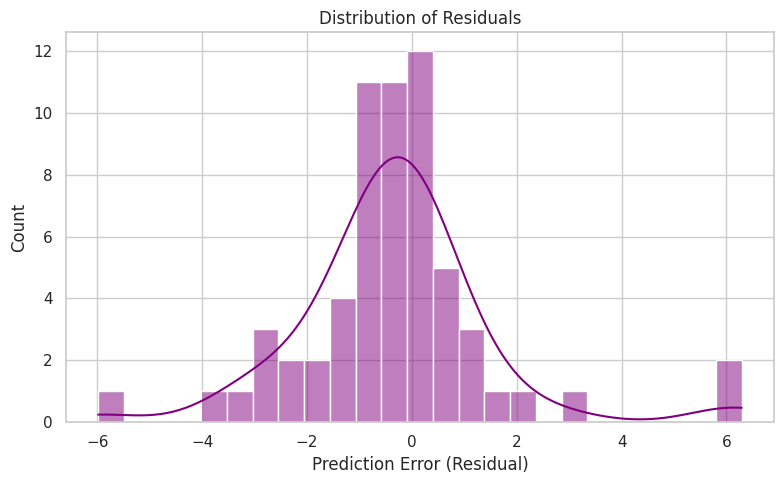

In [ ]:
#  Visualization - Residuals
residuals = y_test - y_pred

plt.figure(figsize=(8, 5))
sns.histplot(residuals, bins=25, kde=True, color='purple')
plt.xlabel('Prediction Error (Residual)')
plt.title('Distribution of Residuals')
plt.tight_layout()
plt.show()
